In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
from utils import RAW_DATA_PATH, MODELS_DIR, RANDOM_STATE
from preprocessing import load_and_prepare_target
from sklearn.model_selection import train_test_split

df = pd.read_csv(RAW_DATA_PATH)
X, y = load_and_prepare_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

best_pipeline = joblib.load(f"{MODELS_DIR}/best_model.joblib")
print("Loaded best model pipeline.")

Loaded best model pipeline.


In [2]:
# Extract transformed data + model for SHAP

# Apply preprocessing (everything except SMOTE/model) to get clean feature matrix
feature_eng_step = best_pipeline.named_steps["feature_engineering"]
encode_step = best_pipeline.named_steps["encode"]
model_step = best_pipeline.named_steps["model"]

# Run X_test through the same two preprocessing stages the model was trained on
# (skip "smote" — SMOTE must never be applied to test/inference data)
X_test_fe = feature_eng_step.transform(X_test)
X_test_transformed = encode_step.transform(X_test_fe)

# Get feature names after one-hot encoding
feature_names = encode_step.get_feature_names_out()

X_test_df = pd.DataFrame(
    X_test_transformed.toarray() if hasattr(X_test_transformed, "toarray") else X_test_transformed,
    columns=feature_names
)

X_test_df.head()

,onehot__Department_Research & Development,onehot__Department_Sales,onehot__JobRole_Human Resources,onehot__JobRole_Laboratory Technician,onehot__JobRole_Manager,onehot__JobRole_Manufacturing Director,onehot__JobRole_Research Director,onehot__JobRole_Research Scientist,onehot__JobRole_Sales Executive,onehot__JobRole_Sales Representative,...,remainder__YearsInCurrentRole,remainder__YearsSinceLastPromotion,remainder__YearsWithCurrManager,remainder__PromotionStagnationIndex,remainder__IncomePerExperience,remainder__LoyaltyScore,remainder__CareerVelocity,remainder__SatisfactionComposite,remainder__OvertimeBurdenFlag,remainder__RoleStability
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.000000,1016.500000,0.000000,0.500000,3.0,0.0,0.000000
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,5.0,7.0,7.0,0.636364,182.818182,0.636364,0.090909,3.0,0.0,0.454545
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,1.0,0.000000,1050.636364,0.166667,0.272727,3.0,0.0,0.666667
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,9.0,14.0,13.0,0.538462,710.740741,0.500000,0.185185,2.5,0.0,0.346154
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,1129.333333,0.000000,0.333333,2.5,1.0,0.000000


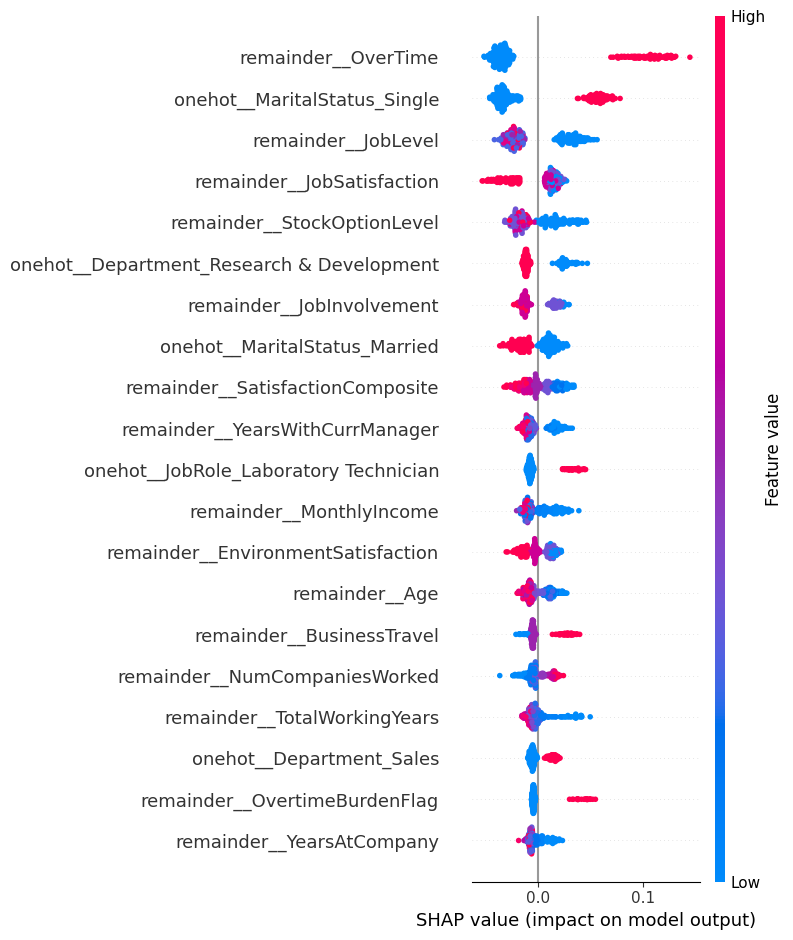

In [3]:
# Global SHAP Summary Plot
explainer = shap.Explainer(model_step, X_test_df)
shap_values = explainer(X_test_df)

# Random Forest (and other classifiers) return SHAP values per class.
# We want class 1 = "Leave" (the attrition-positive class).
if len(shap_values.shape) == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

shap.summary_plot(shap_values_class1, X_test_df, show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
# SHAP Feature Importance Table (for feature selection validation)
mean_abs_shap = np.abs(shap_values_class1.values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df.head(15).to_string(index=False))
print("\nLow-importance candidates for removal:")
print(importance_df[importance_df["mean_abs_shap"] < 0.005].to_string(index=False))

                                  feature  mean_abs_shap
                      remainder__OverTime       0.053180
             onehot__MaritalStatus_Single       0.040919
                      remainder__JobLevel       0.027052
               remainder__JobSatisfaction       0.019263
              remainder__StockOptionLevel       0.018512
onehot__Department_Research & Development       0.016094
                remainder__JobInvolvement       0.014679
            onehot__MaritalStatus_Married       0.014237
         remainder__SatisfactionComposite       0.013014
          remainder__YearsWithCurrManager       0.011469
    onehot__JobRole_Laboratory Technician       0.011387
                 remainder__MonthlyIncome       0.011329
       remainder__EnvironmentSatisfaction       0.011270
                           remainder__Age       0.009728
                remainder__BusinessTravel       0.009558

Low-importance candidates for removal:
                                feature  mean_ab

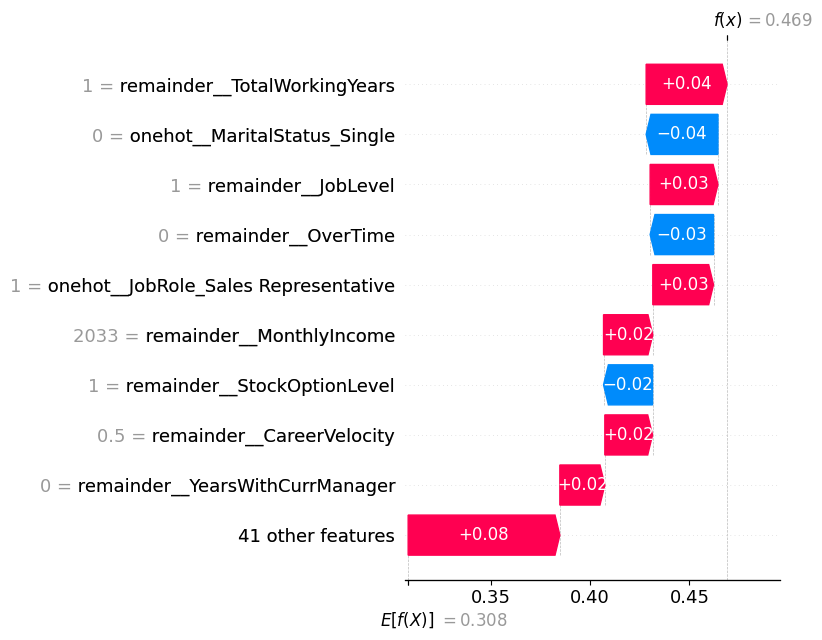

Predicted attrition probability: 46.89%


X has feature names, but RandomForestClassifier was fitted without feature names


In [5]:
# Local Explanation: Waterfall Plot for One Employee
employee_idx = 0  # pick any test employee

shap.plots.waterfall(shap_values_class1[employee_idx], show=False)
plt.tight_layout()
plt.savefig("../reports/figures/shap_waterfall_employee.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Predicted attrition probability: {model_step.predict_proba(X_test_df)[employee_idx][1]:.2%}")